CONECTANDO SQL COM PANDAS

In [1]:
import sqlite3
import pandas as pd

conecxao = sqlite3.connect('status_brasil')

In [4]:
print(conecxao)

In [2]:
import os
print(os.getcwd())  # mostra o diretório atual

c:\Users\vkere\OneDrive\Documentos\GitHub\ProgrAmo---Analise-de-Dados\Modulo5


In [6]:
query = "SELECT * FROM Municipios_Brasileiros WHERE Cidade = 'Itaquaquecetuba';"

In [7]:
query

"SELECT * FROM Municipios_Brasileiros WHERE Cidade = 'Itaquaquecetuba';"

In [8]:
pd.read_sql(query, con=conecxao)

,Cidade,Estado,Regiao,municipio_ID
0,Itaquaquecetuba,SP,Sudeste,5043


In [9]:

import pandas as pd
dados2 = pd.read_excel('../Modulo4/Planilha_Aula_parte2.xlsx')
dados = pd.read_excel("../Modulo3/planilha_modulo3.xlsx")
dados = dados.merge(dados2, on='ID', how='left')


In [10]:
lista_estados = list(dados['UF ONDE MORA'].unique())

In [11]:
query = '''
    SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.renda) 
    FROM Municipios_Brasileiros                                 
    INNER JOIN Municipio_Status 
        ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID 
    WHERE Municipios_Brasileiros.Estado IN ({})      
    GROUP BY Municipios_Brasileiros.Estado;
'''.format(','.join(['?' for _ in lista_estados]))                          
#AVG calcula a média

In [12]:
estados_renda = pd.read_sql(query, con=conecxao, params=lista_estados)

In [13]:
dados.rename(columns={'UF ONDE MORA':'Estado'}, inplace=True)

In [14]:
dados = dados.merge(estados_renda, on='Estado', how='left')

In [15]:
correlacao_renda_salario = dados['SALARIO'].corr(dados['AVG(Municipio_Status.renda)'])
correlacao_renda_salario

np.float64(0.07248666687783033)

In [16]:
print(dados.columns.tolist())

['Unnamed: 0', 'ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD', 'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS', 'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'Estado', 'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM', 'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO', 'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR', 'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL', 'NIVEL', 'FAIXA SALARIAL', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?', 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?', 'SALARIO', 'Quanto tempo de experiência na área de dados você tem?', 'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?', 'Você está satisfeito na sua empresa atual?', 'Qual o principal motivo da sua insatisfação com a empresa atual?', 'Você participou de entrevistas de emprego nos últimos 6 meses?', 'V

In [2]:
a ='Batata'
print('eu gosto de '+a)
print(f'eu gosto de {a}')

eu gosto de Batata
eu gosto de Batata


In [5]:
a = ['batata',' tomate',' alface']
print('eu gosto de {}, {} e {}'.format(a[0], a[1], a[2]))

eu gosto de batata,  tomate e  alface


In [6]:
print('eu gosto de {}'.format(','.join(a)))

eu gosto de batata, tomate, alface


In [17]:
#SQLePandasCheck
query = '''
    SELECT Municipios_Brasileiros.Estado, AVG(Municipio_Status.Educacao) AS media_educacao
    FROM Municipios_Brasileiros                                 
    INNER JOIN Municipio_Status 
        ON Municipios_Brasileiros.municipio_ID = Municipio_Status.municipio_ID 
    WHERE Municipios_Brasileiros.Estado IN ({})      
    GROUP BY Municipios_Brasileiros.Estado;
'''.format(','.join(['?' for _ in lista_estados]))

Media_Educacao = pd.read_sql(query, conecxao, params=lista_estados)
dados = dados.merge(Media_Educacao, on='Estado', how='left')
correlacao_edu_salario = dados['SALARIO'].corr(dados['media_educacao'])
correlacao_edu_salario

np.float64(0.0864208141874599)

VISUALIZAÇÃO DE DADOS

In [3]:
import pandas as pd
dados = pd.read_csv('../Modulo5/analise_dados.csv')

In [4]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,False,False
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,True,False
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,False,True
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,False,True
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,False,True


In [6]:
genero_counts = dados['GENERO'].value_counts()

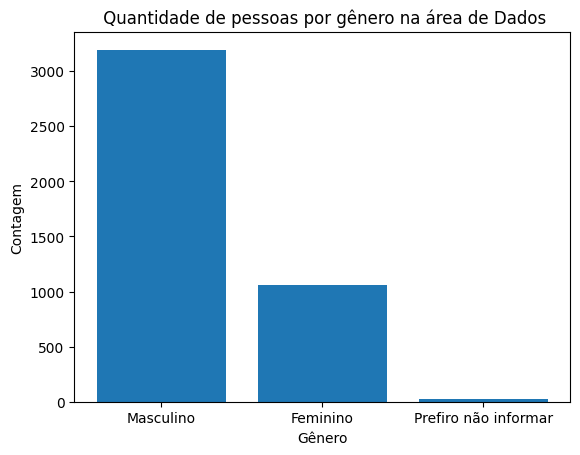

In [7]:
import matplotlib.pyplot as plt
plt.Figure()
plt.bar(height= genero_counts.values, x = genero_counts.index)
plt.title(' Quantidade de pessoas por gênero na área de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show()

C:\Users\vkere\AppData\Local\Temp\ipykernel_4044\89903480.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = dados, x = 'GENERO', palette = 'pastel')


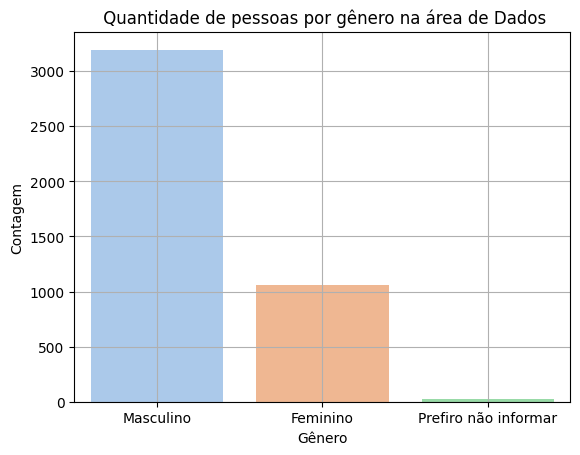

In [8]:
import seaborn as sns
plt.figure()
sns.countplot(data = dados, x = 'GENERO', palette = 'pastel')
plt.title(' Quantidade de pessoas por gênero na área de Dados')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.grid(True)
plt.show()


In [11]:
dados['SALARIO'] = dados['SALARIO'].str.replace(",", ".")
dados['SALARIO'] = pd.to_numeric(dados['SALARIO'])
dados['IDADE'] = pd.to_numeric(dados['IDADE'], errors='coerce')
dados = dados.dropna(subset=['IDADE'])
dados['IDADE'] = dados['IDADE'].astype(int)
salario_por_idade = dados.groupby("IDADE")['SALARIO'].mean()
salario_por_idade = salario_por_idade.sort_index()

In [50]:
salario_por_idade

IDADE
18     4230.307692
19     4519.590909
20     5004.272727
21     4578.737179
22     4394.689815
23     5602.406897
24     6151.622449
25     7616.392336
26     7700.071174
27     8237.429766
28     9737.938144
29     9554.853146
30    10316.412685
31    10021.462609
32    10843.197778
33    11592.718589
34    12294.640212
35    12435.845103
36    12267.966532
37    12613.528356
38    13802.724872
39    13309.082893
40    15028.032716
41    13578.880952
42    11801.037037
43    14349.732275
44    14665.770143
45    16103.431512
46    11913.709677
47    11156.031250
48    12249.714286
49    13537.450000
50    15740.010176
51     8977.900000
52    11779.475000
53     9850.000000
54    13644.142000
Name: SALARIO, dtype: float64

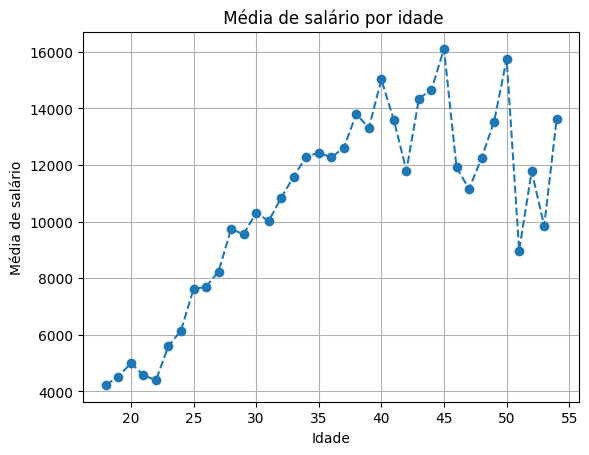

In [12]:
plt.figure()
plt.plot(salario_por_idade.index, salario_por_idade.values, marker='o', linestyle='--')
plt.title(' Média de salário por idade')
plt.xlabel('Idade')
plt.ylabel('Média de salário')
plt.grid(True)
plt.show()


In [13]:
import plotly.express as px

In [14]:
fig = px.line(salario_por_idade.reset_index(), x = 'IDADE', y= 'SALARIO', title=' Média de salário por idade', markers = True )
fig.show()

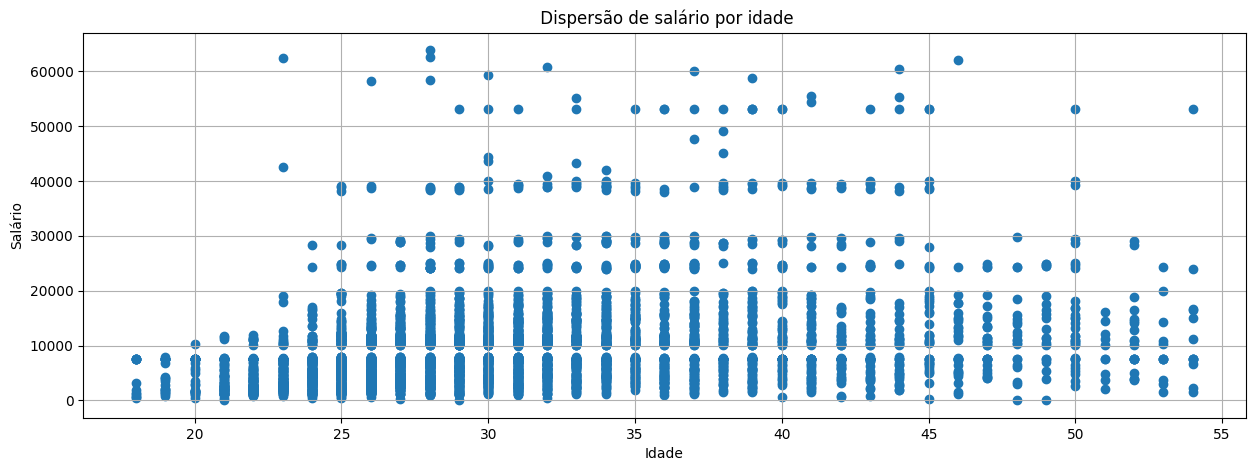

In [15]:
plt.figure(figsize=(15,5))
plt.scatter(dados['IDADE'], dados['SALARIO'], alpha= 1)
plt.title(' Dispersão de salário por idade')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.grid(True)
plt.show()

In [18]:
fig = px.scatter(dados, x ='IDADE', y='SALARIO', title = 'Dispersão de salário por idade')
fig.show()